# Notebook 02: Exploratory Data Analysis (Basic)
## Weather Trend Forecasting — PM Accelerator Assessment
### Goal: Uncover trends, correlations, and patterns in the global weather data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Paths
PROCESSED_DATA = Path('../data/processed/weather_cleaned.csv')
FIGURES_DIR = Path('../outputs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DATA, parse_dates=['last_updated'])
print(f"Loaded: {df.shape}")
print(f"Date range: {df['last_updated'].min()} → {df['last_updated'].max()}")

Loaded: (144822, 39)
Date range: 2024-05-16 01:45:00 → 2026-06-01 19:15:00


## 1. Temperature Distribution

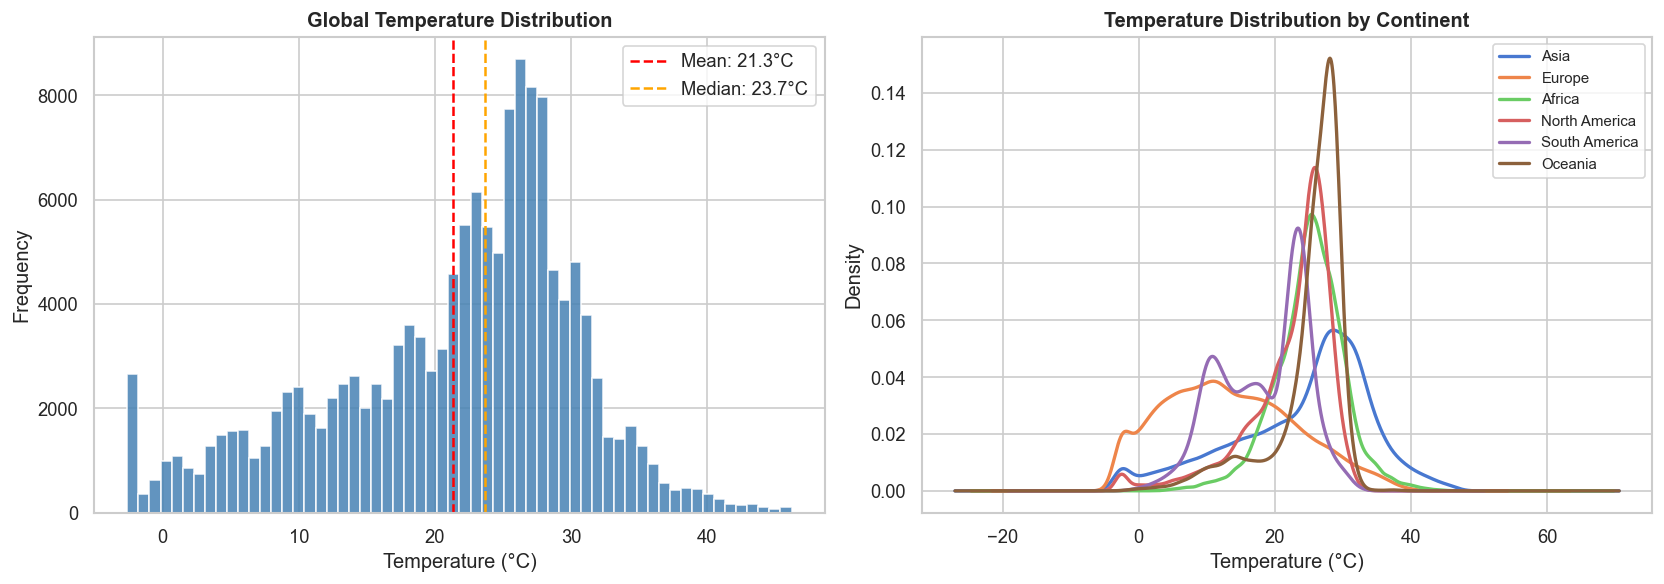

 Saved: 03_temperature_distribution.png


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['temperature_celsius'].dropna(), bins=60,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['temperature_celsius'].mean(), color='red',
                linestyle='--', linewidth=1.5, label=f"Mean: {df['temperature_celsius'].mean():.1f}°C")
axes[0].axvline(df['temperature_celsius'].median(), color='orange',
                linestyle='--', linewidth=1.5, label=f"Median: {df['temperature_celsius'].median():.1f}°C")
axes[0].set_title('Global Temperature Distribution', fontweight='bold')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# KDE by continent
for continent in df['continent'].unique():
    subset = df[df['continent'] == continent]['temperature_celsius'].dropna()
    subset.plot(kind='kde', ax=axes[1], label=continent, linewidth=2)
axes[1].set_title('Temperature Distribution by Continent', fontweight='bold')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_temperature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 03_temperature_distribution.png")

## 2. Temperature by Country (Top & Bottom 20)

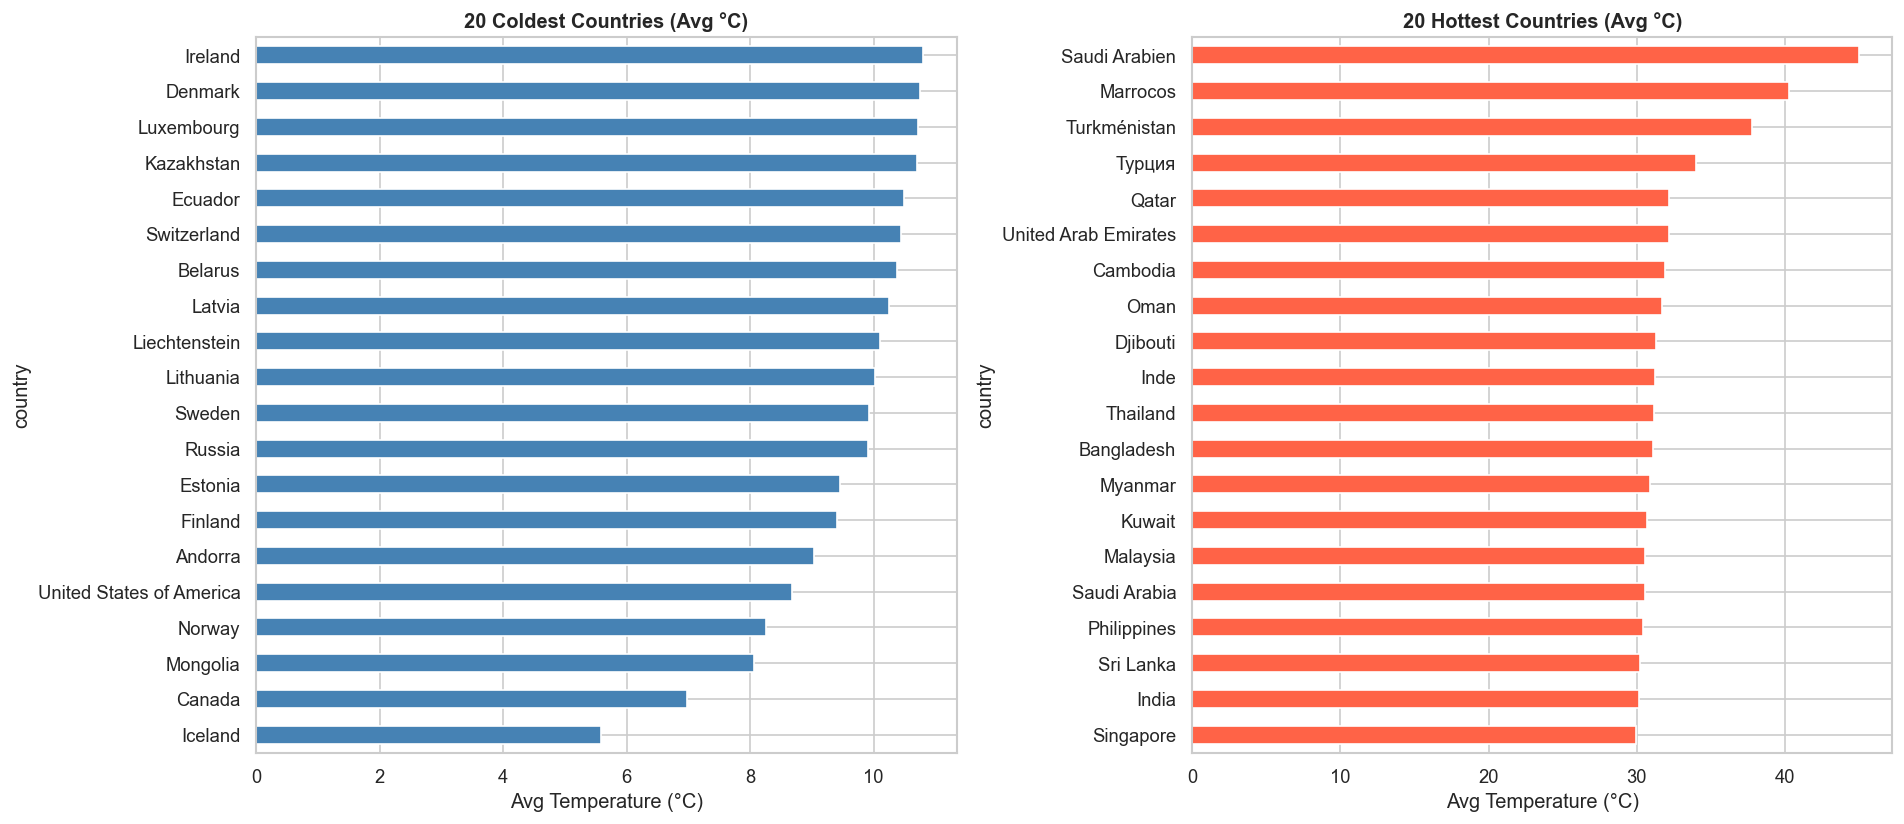

 Saved: 04_temperature_by_country.png


In [3]:
country_temp = df.groupby('country')['temperature_celsius'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Coldest 20
country_temp.head(20).plot(kind='barh', ax=axes[0],
                            color='steelblue', edgecolor='white')
axes[0].set_title('20 Coldest Countries (Avg °C)', fontweight='bold')
axes[0].set_xlabel('Avg Temperature (°C)')

# Hottest 20
country_temp.tail(20).plot(kind='barh', ax=axes[1],
                            color='tomato', edgecolor='white')
axes[1].set_title('20 Hottest Countries (Avg °C)', fontweight='bold')
axes[1].set_xlabel('Avg Temperature (°C)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_temperature_by_country.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 04_temperature_by_country.png")

## 3. Temperature by Continent

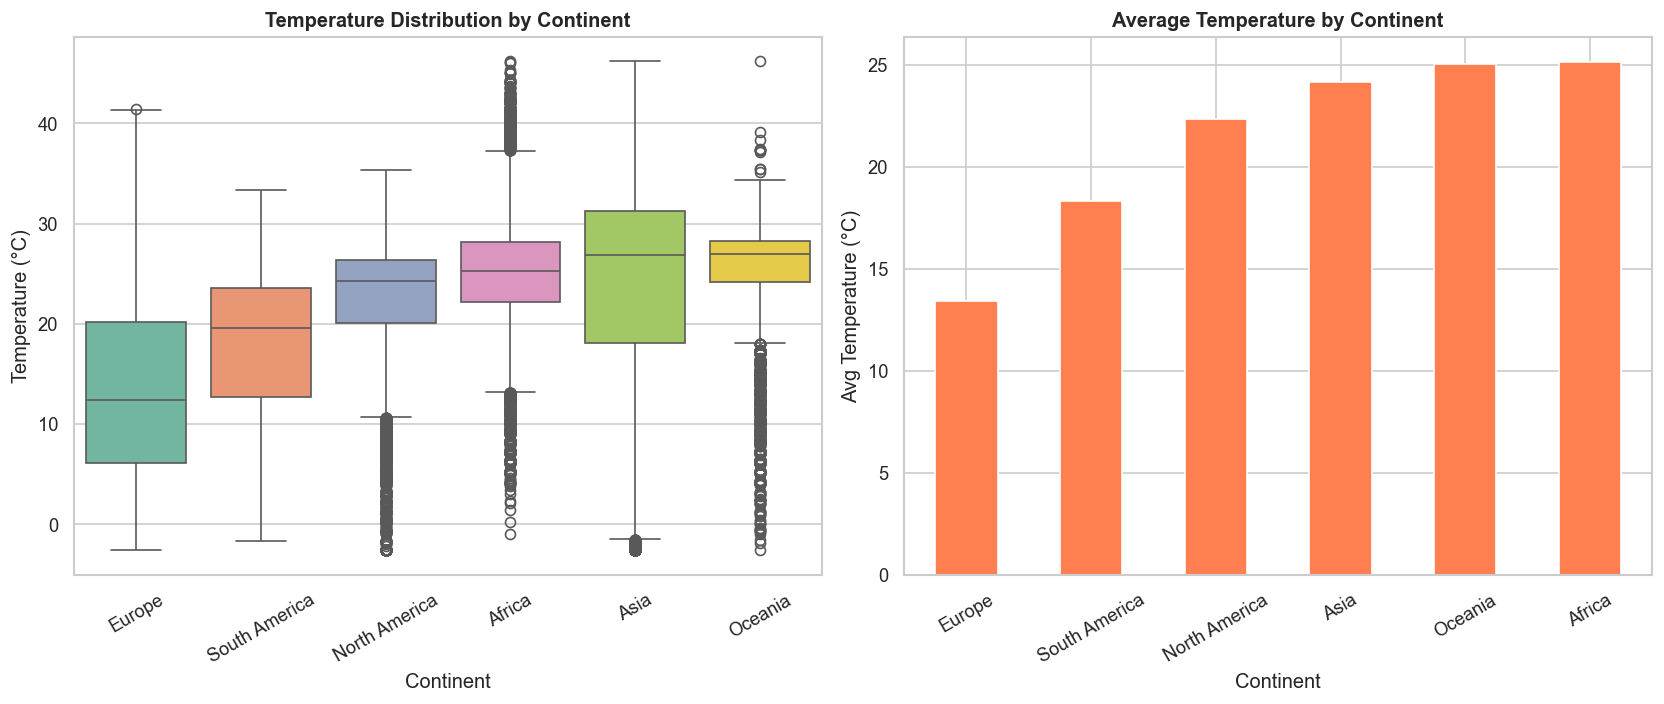

Saved: 05_temperature_by_continent.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
continent_order = df.groupby('continent')['temperature_celsius'].median().sort_values().index
sns.boxplot(data=df, x='continent', y='temperature_celsius',
            order=continent_order, palette='Set2', ax=axes[0])
axes[0].set_title('Temperature Distribution by Continent', fontweight='bold')
axes[0].set_xlabel('Continent')
axes[0].set_ylabel('Temperature (°C)')
axes[0].tick_params(axis='x', rotation=30)

# Bar chart - mean temp
continent_mean = df.groupby('continent')['temperature_celsius'].mean().sort_values()
continent_mean.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Average Temperature by Continent', fontweight='bold')
axes[1].set_xlabel('Continent')
axes[1].set_ylabel('Avg Temperature (°C)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_temperature_by_continent.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_temperature_by_continent.png")

## 4. Precipitation Analysis

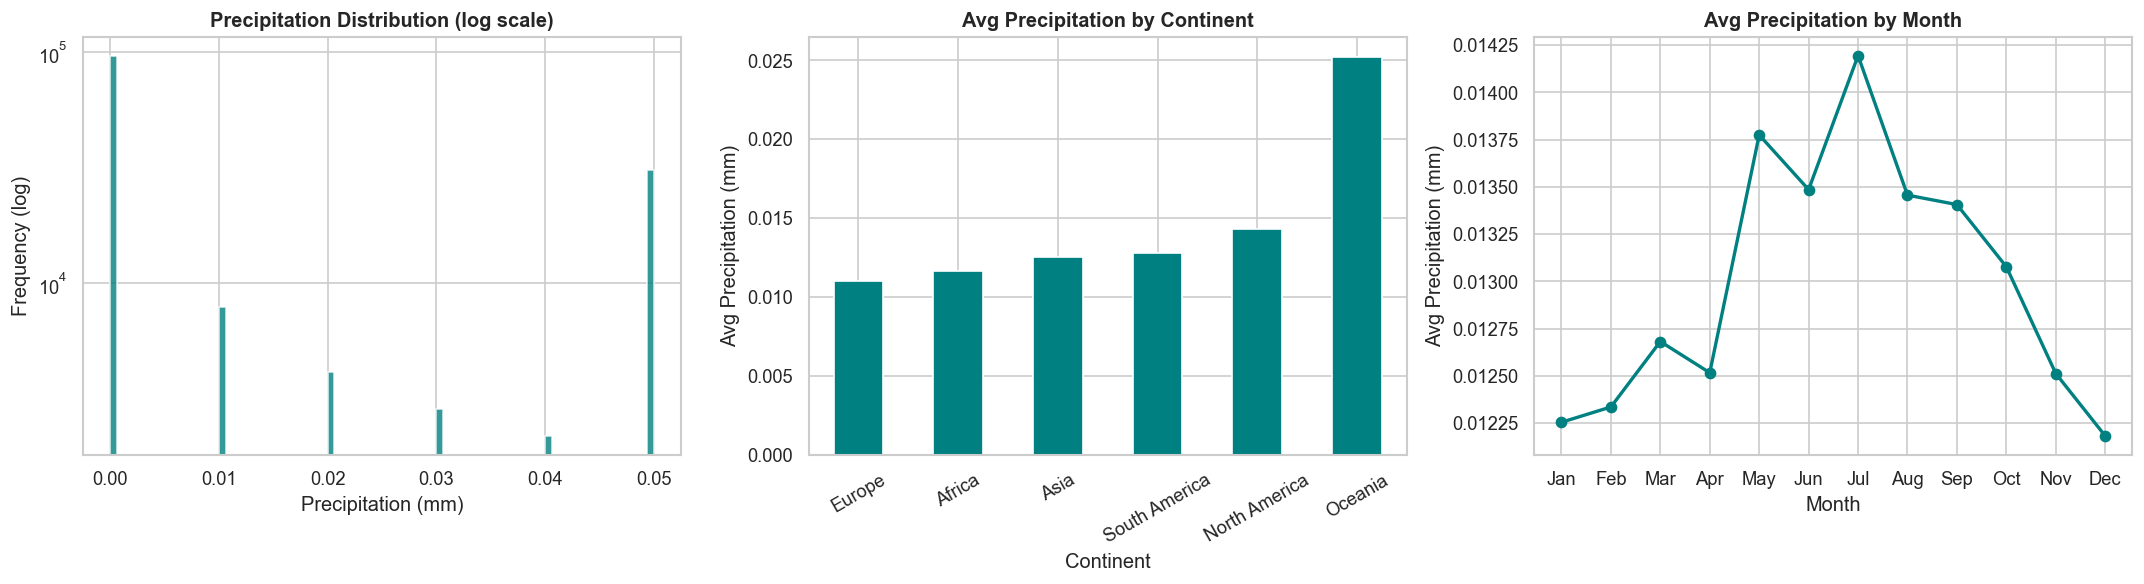

Saved: 06_precipitation_analysis.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution (log scale)
axes[0].hist(df['precip_mm'].dropna(), bins=80,
             color='teal', edgecolor='white', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_title('Precipitation Distribution (log scale)', fontweight='bold')
axes[0].set_xlabel('Precipitation (mm)')
axes[0].set_ylabel('Frequency (log)')

# By continent
continent_precip = df.groupby('continent')['precip_mm'].mean().sort_values()
continent_precip.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Avg Precipitation by Continent', fontweight='bold')
axes[1].set_xlabel('Continent')
axes[1].set_ylabel('Avg Precipitation (mm)')
axes[1].tick_params(axis='x', rotation=30)

# By month
monthly_precip = df.groupby('month')['precip_mm'].mean()
monthly_precip.plot(kind='line', ax=axes[2], marker='o',
                    color='teal', linewidth=2, markersize=6)
axes[2].set_title('Avg Precipitation by Month', fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Avg Precipitation (mm)')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_precipitation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_precipitation_analysis.png")

## 5. Seasonal Patterns

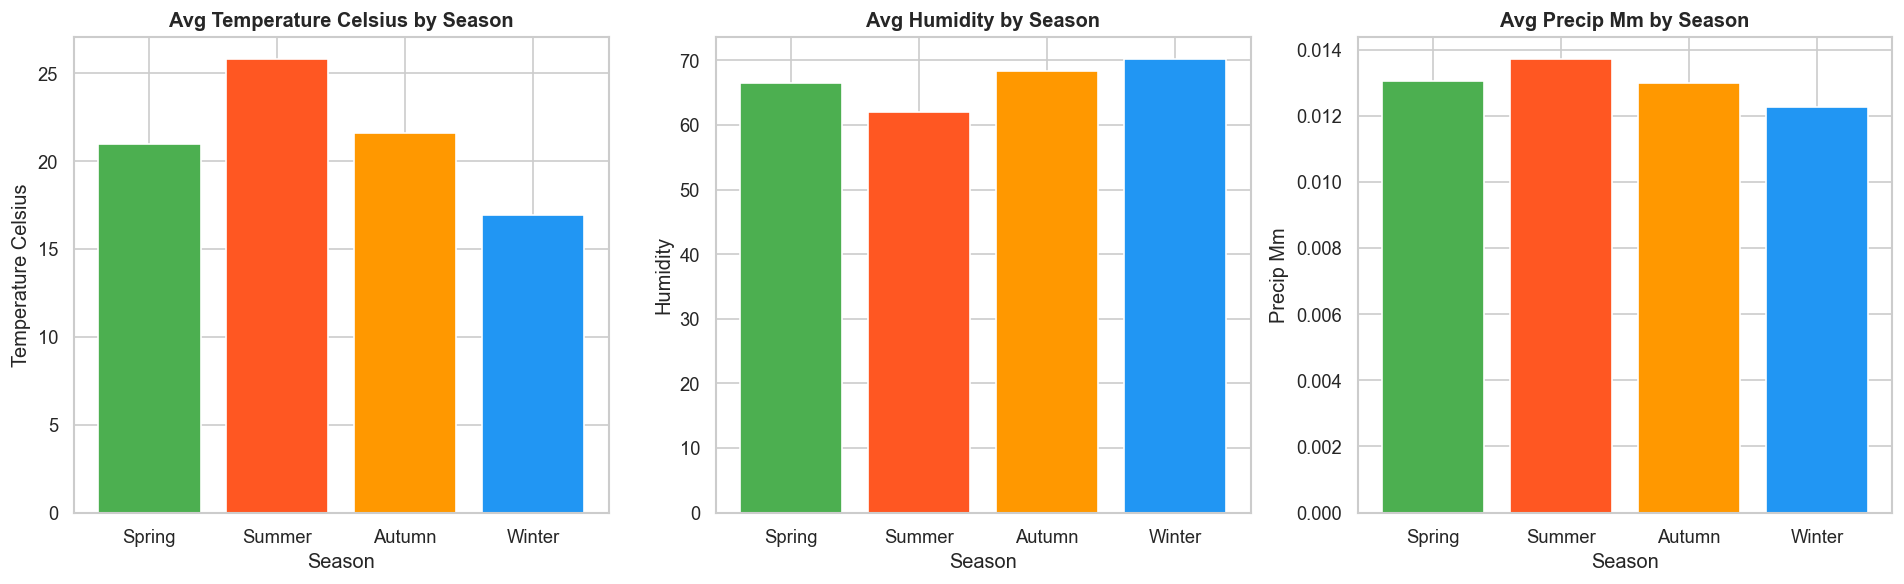

Saved: 07_seasonal_patterns.png


In [6]:
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_stats = df.groupby('season')[['temperature_celsius',
                                      'humidity', 'precip_mm']].mean()
season_stats = season_stats.reindex(season_order)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4CAF50', '#FF5722', '#FF9800', '#2196F3']

for i, col in enumerate(['temperature_celsius', 'humidity', 'precip_mm']):
    axes[i].bar(season_order, season_stats[col], color=colors, edgecolor='white')
    axes[i].set_title(f'Avg {col.replace("_", " ").title()} by Season',
                       fontweight='bold')
    axes[i].set_xlabel('Season')
    axes[i].set_ylabel(col.replace('_', ' ').title())

plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_seasonal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 07_seasonal_patterns.png")

## 6. Monthly Temperature Trends Over Time

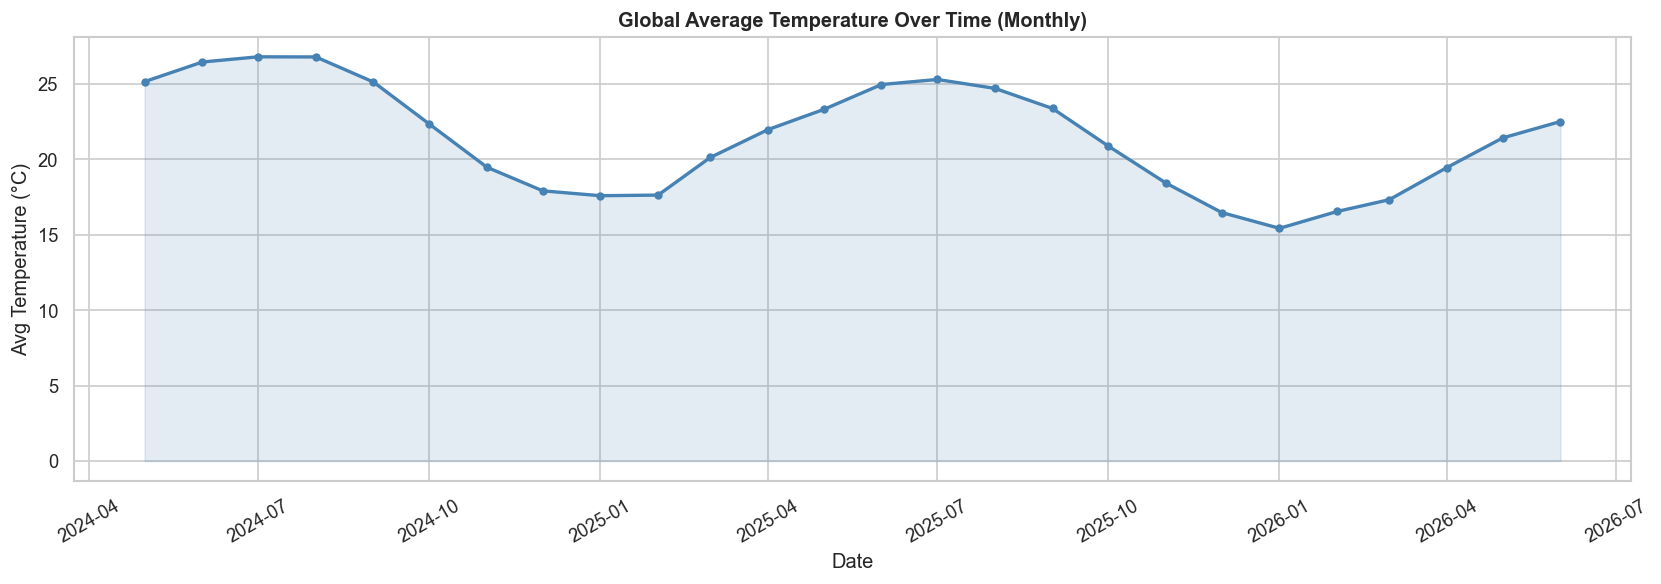

Saved: 08_monthly_temperature_trend.png


In [7]:
monthly_trend = df.groupby(df['last_updated'].dt.to_period('M'))['temperature_celsius'].mean()
monthly_trend.index = monthly_trend.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_trend.index, monthly_trend.values,
        color='steelblue', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly_trend.index, monthly_trend.values,
                alpha=0.15, color='steelblue')
ax.set_title('Global Average Temperature Over Time (Monthly)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Temperature (°C)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_monthly_temperature_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 08_monthly_temperature_trend.png")

## 7. Correlation Heatmap

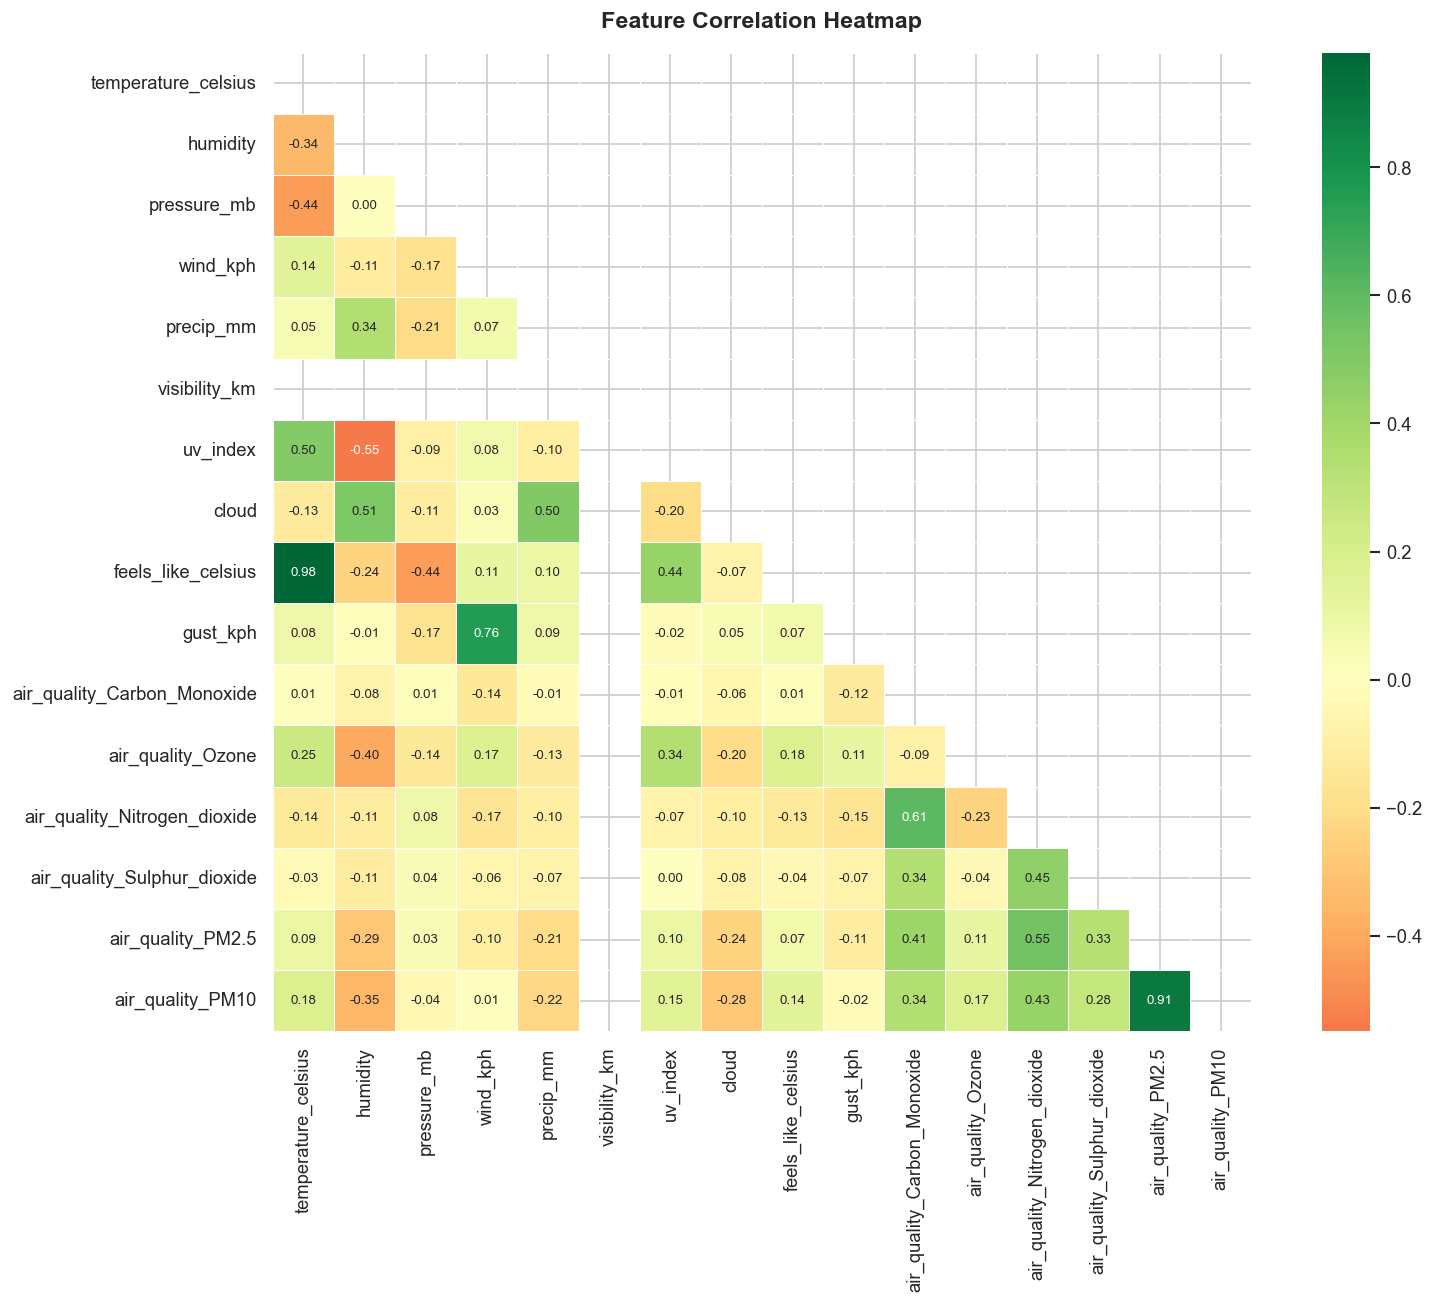

Saved: 09_correlation_heatmap.png


In [8]:
corr_cols = [
    'temperature_celsius', 'humidity', 'pressure_mb', 'wind_kph',
    'precip_mm', 'visibility_km', 'uv_index', 'cloud',
    'feels_like_celsius', 'gust_kph',
    'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5', 'air_quality_PM10'
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 09_correlation_heatmap.png")

## 8. Wind & Humidity Analysis

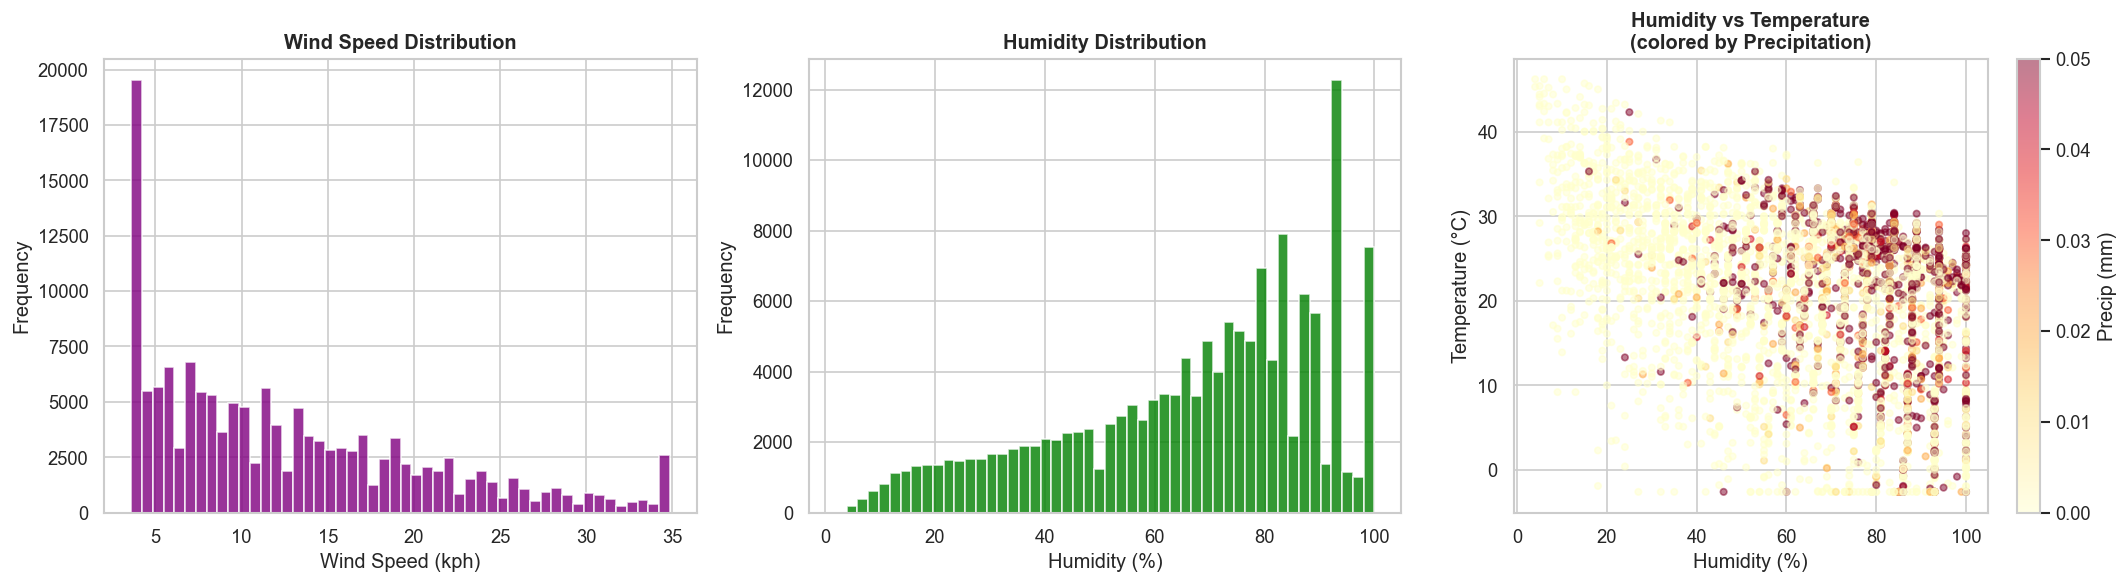

Saved: 10_wind_humidity_analysis.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Wind speed distribution
axes[0].hist(df['wind_kph'].dropna(), bins=50,
             color='purple', edgecolor='white', alpha=0.8)
axes[0].set_title('Wind Speed Distribution', fontweight='bold')
axes[0].set_xlabel('Wind Speed (kph)')
axes[0].set_ylabel('Frequency')

# Humidity distribution
axes[1].hist(df['humidity'].dropna(), bins=50,
             color='green', edgecolor='white', alpha=0.8)
axes[1].set_title('Humidity Distribution', fontweight='bold')
axes[1].set_xlabel('Humidity (%)')
axes[1].set_ylabel('Frequency')

# Humidity vs Temperature scatter
sample = df.sample(5000, random_state=42)
scatter = axes[2].scatter(sample['humidity'], sample['temperature_celsius'],
                           c=sample['precip_mm'], cmap='YlOrRd',
                           alpha=0.5, s=15)
plt.colorbar(scatter, ax=axes[2], label='Precip (mm)')
axes[2].set_title('Humidity vs Temperature\n(colored by Precipitation)',
                   fontweight='bold')
axes[2].set_xlabel('Humidity (%)')
axes[2].set_ylabel('Temperature (°C)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_wind_humidity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 10_wind_humidity_analysis.png")

## 9. Weather Conditions Distribution

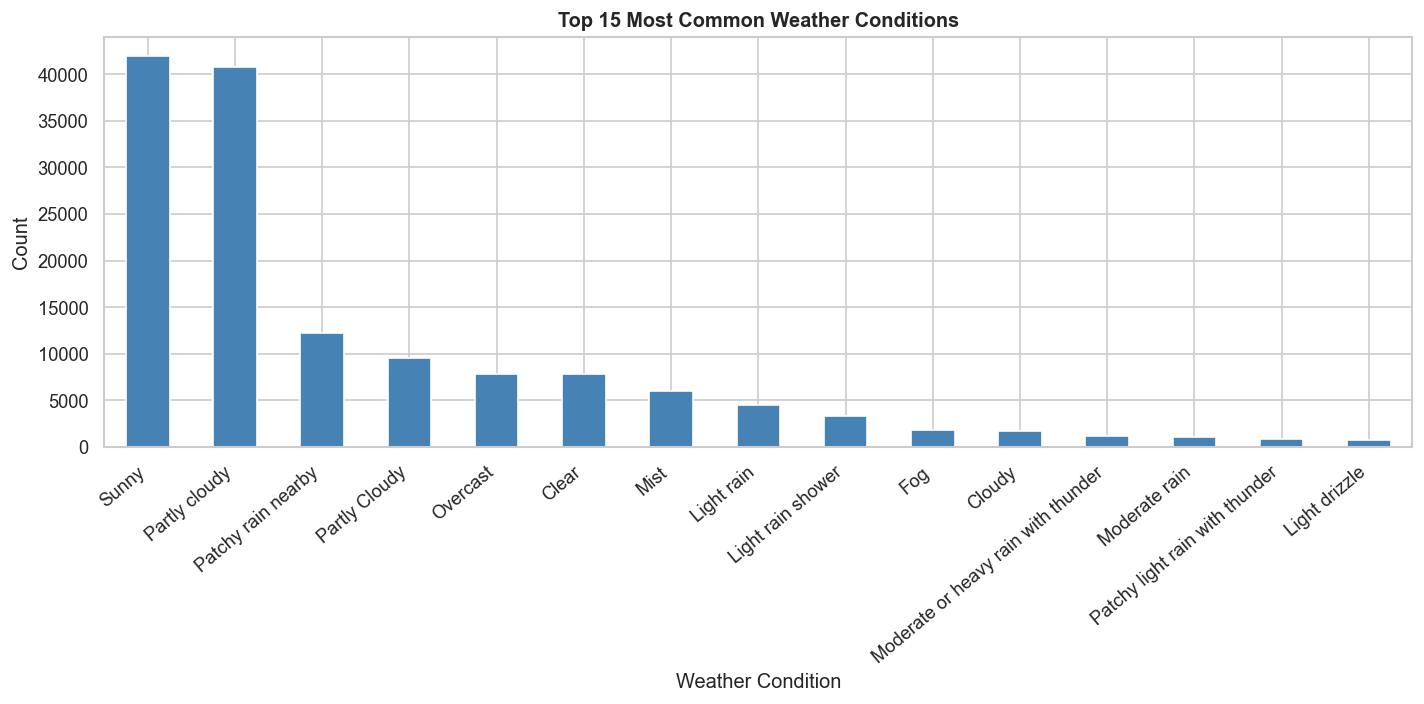

 Saved: 11_weather_conditions.png


In [10]:
# Top 15 weather conditions
top_conditions = df['condition_text'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_conditions.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Most Common Weather Conditions', fontweight='bold')
ax.set_xlabel('Weather Condition')
ax.set_ylabel('Count')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '11_weather_conditions.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 11_weather_conditions.png")